

### 1) Import Pandas


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### 2) Import the dataset and  Assign it to a variable called users and use the 'user_id' as index

Use the following dataset
https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user


In [3]:
users = pd.read_csv('https://raw.githubusercontent.com/justmarkham/DAT8/master/data/u.user', sep = '|')
users.set_index('user_id')
users

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


### 3) Display the first 25 entries

In [4]:
users.head(25)

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
5,6,42,M,executive,98101
6,7,57,M,administrator,91344
7,8,36,M,administrator,05201
8,9,29,M,student,01002
9,10,53,M,lawyer,90703


### 4) Display the last 10 entries

In [5]:
users.tail(10)

,user_id,age,gender,occupation,zip_code
933,934,61,M,engineer,22902
934,935,42,M,doctor,66221
935,936,24,M,other,32789
936,937,48,M,educator,98072
937,938,38,F,technician,55038
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209
942,943,22,M,student,77841


### 5) What is the number of observations in the dataset?

In [6]:
print(f'Number of obs: {users.shape[0]}')

Number of obs: 943


### 6) What is the number of columns in the dataset, also print the name of all the columns?

In [7]:
print(f'No. of columns:{users.shape[1]}')
users.columns

No. of columns:5


Index(['user_id', 'age', 'gender', 'occupation', 'zip_code'], dtype='str')

### 7) What is the data type of each column?

In [8]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     943 non-null    int64
 1   age         943 non-null    int64
 2   gender      943 non-null    str  
 3   occupation  943 non-null    str  
 4   zip_code    943 non-null    str  
dtypes: int64(2), str(3)
memory usage: 37.0 KB


### 8) Print only the occupation column

In [9]:
users['occupation']

0         technician
1              other
2             writer
3         technician
4              other
           ...      
938          student
939    administrator
940          student
941        librarian
942          student
Name: occupation, Length: 943, dtype: str

### 9) How many different occupations are in this dataset?


In [10]:
x = len(users.groupby('occupation')['occupation'])
print(f'{x} different occupations present in the dataset')

21 different occupations present in the dataset


### 10) What is the most frequent occupation?

In [11]:
m = users.groupby('occupation')['occupation'].count()
name = m.idxmax()
count = m.max()
print(f'Occupation: {name}, Count: {count}')

Occupation: student, Count: 196


### 11) Summarize the DataFrame.

In [12]:
users.describe(include = 'all')

,user_id,age,gender,occupation,zip_code
count,943.000000,943.000000,943,943,943
unique,NaN,NaN,2,21,795
top,NaN,NaN,M,student,55414
freq,NaN,NaN,670,196,9
mean,472.000000,34.051962,NaN,NaN,NaN
std,272.364951,12.192740,NaN,NaN,NaN
min,1.000000,7.000000,NaN,NaN,NaN
25%,236.500000,25.000000,NaN,NaN,NaN
50%,472.000000,31.000000,NaN,NaN,NaN
75%,707.500000,43.000000,NaN,NaN,NaN


### 12) Summarize only the occupation column

In [13]:
users.occupation.describe()

count         943
unique         21
top       student
freq          196
Name: occupation, dtype: object

### 13) What is the mean age of users?

In [14]:
print(f'Mean age of users: {users.age.mean():.2f}')

Mean age of users: 34.05


### 14) What is the age with least occurrence?

In [15]:
t =users.groupby('age')['age'].count()
print(f'The age with the least occurrence: {t.idxmin()}, and the no. of occurrences are: {t.min()}')

The age with the least occurrence: 7, and the no. of occurrences are: 1


### 15) What is the zip code with most occurrence?

In [16]:
z =users.groupby('zip_code')['zip_code'].count()
print(f'The zip code with the most occurrence: {t.idxmax()}, and the no. of occurrences are: {t.max()}')

The zip code with the most occurrence: 30, and the no. of occurrences are: 39


### 16) Which profession has youngest people(apart from student)? Show the trend of mean age of people with profession as the seperating factor.

profession with the youngest age: entertainment with the avg age: 29.22222222222222


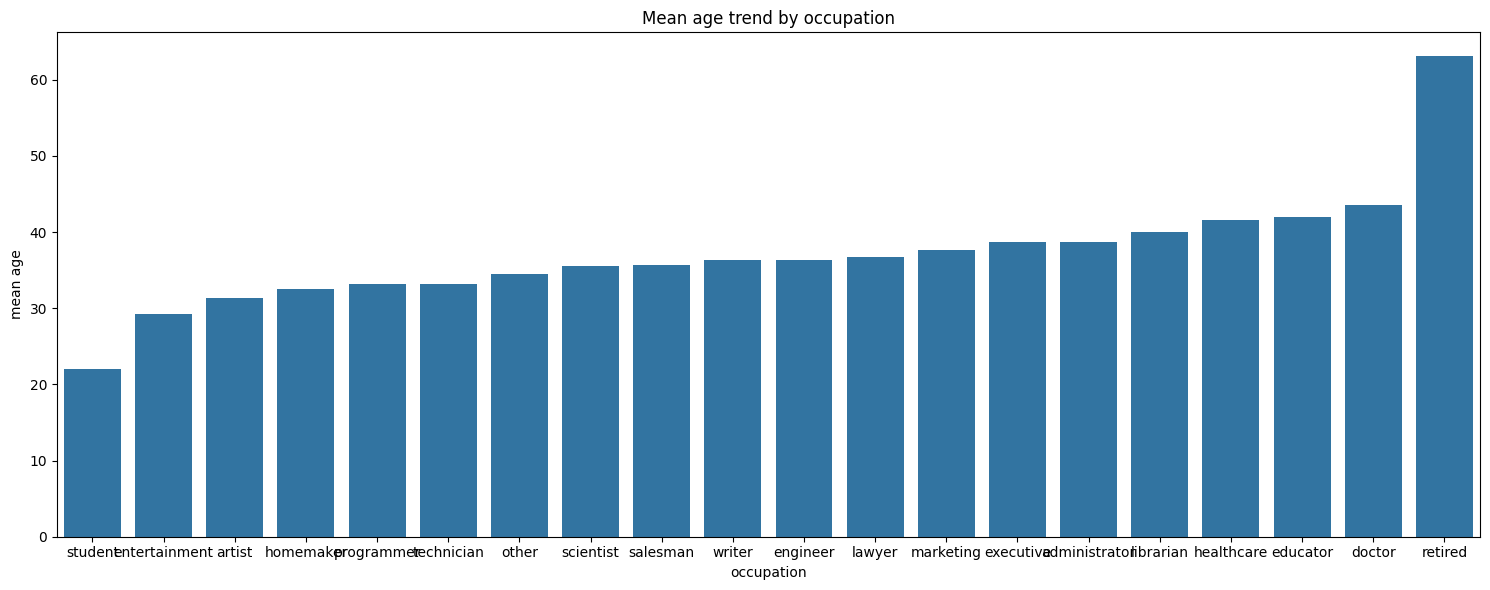

In [35]:
q = (users[users.occupation != 'none'].groupby('occupation')['age'].mean().sort_values())
print(f'profession with the youngest age: {q.index[1]} with the avg age: {q.iloc[1]}')

#to show the trend of mean of age of people with profession as separating factor, we use the bar graph
plt.figure(figsize = (15, 6))
sns.barplot(x = q.index,
            y = q.values,
            )

plt.xlabel('occupation')
plt.ylabel('mean age')
plt.title('Mean age trend by occupation')
plt.tight_layout()
plt.show()